<a href="https://colab.research.google.com/github/will-mccormack/CS-M148-Proj/blob/main/COM_SCI_M148_NN_with_genre_with_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from sklearn.preprocessing import StandardScaler
import time
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [30]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from matplotlib import lines

In [31]:
train_filepath = "https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/train.csv"
validation_filepath = "https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/validation.csv"

train_data_raw = pd.read_csv(train_filepath)
validation_data_raw = pd.read_csv(train_filepath)

In [32]:
# device setup to find gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [33]:
"""
def load_data(train_path, val_path):
  train_data = pd.read_csv(train_path)
  val_data = pd.read_csv(val_path)
  train_data['explicit'] = train_data['explicit'].astype(int)
  val_data['explicit'] = val_data['explicit'].astype(int)
  train_data = pd.get_dummies(train_data, columns=['track_genre'], dtype=float)
  val_data = pd.get_dummies(val_data, columns=['track_genre'], dtype=float)
  train_cols =train_data.columns
  val_data = val_data.reindex(columns=train_cols, fill_value=0)
  return train_data, val_data
  """
def load_and_align_datasets(train_path, val_path):
    # 1. Load Data
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)

    # 2. Clean 'explicit' column (bool -> int)
    train_df['explicit'] = train_df['explicit'].astype(int)
    val_df['explicit'] = val_df['explicit'].astype(int)

    # 3. One-Hot Encode Genres (Create columns like 'track_genre_pop', 'track_genre_rock')
    train_df = pd.get_dummies(train_df, columns=['track_genre'], dtype=float)
    val_df = pd.get_dummies(val_df, columns=['track_genre'], dtype=float)

    # --- NEW: CONSOLIDATE DUPLICATES ---
    print(f"Rows before consolidation: {len(train_df)}")

    # Identify which columns are Genes vs Musical Features
    genre_cols = [c for c in train_df.columns if c.startswith('track_genre_')]
    feature_cols = [c for c in train_df.columns if c not in genre_cols]

    # Group by all musical features.
    # If two rows have identical features, they are the same song.
    # .max() combines the genre flags (0 and 1 becomes 1).
    train_df = train_df.groupby(feature_cols, as_index=False)[genre_cols].max()

    # Do the same for validation
    val_genre_cols = [c for c in val_df.columns if c.startswith('track_genre_')]
    val_feature_cols = [c for c in val_df.columns if c not in val_genre_cols]
    val_df = val_df.groupby(val_feature_cols, as_index=False)[val_genre_cols].max()

    print(f"Rows after consolidation: {len(train_df)}")
    # -----------------------------------

    # 4. Align Columns (Ensure Train and Val have same genres)
    train_cols = train_df.columns
    val_df = val_df.reindex(columns=train_cols, fill_value=0)

    return train_df, val_df

In [34]:
def calculate_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            preds = model(features).cpu().numpy() # Move to CPU for sklearn

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Convert lists to arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Metrics
    mse = mean_squared_error(all_labels, all_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_labels, all_preds)

    return mse, rmse, r2

In [35]:
class SpotifyDataset(Dataset):
  def __init__(self, dataframe,scaler=None,is_train=True):
    # split x and y
    self.x = dataframe.drop(columns=['popularity','instrumentalness','time_signature','valence']).values
    self.y = dataframe['popularity'].values
    if is_train:
      self.scaler = StandardScaler()
      self.x = self.scaler.fit_transform(self.x) #scale data
    else:
      self.scaler = scaler
      self.x = self.scaler.transform(self.x)

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    features = self.x[idx]
    label = self.y[idx]
    features_tensor = torch.tensor(features, dtype=torch.float32)
    label_tensor = torch.tensor(label, dtype=torch.float32)
    return features_tensor, label_tensor

In [36]:
train_data, val_data = load_and_align_datasets(train_filepath, validation_filepath)

train_dataset = SpotifyDataset(train_data, is_train=True)
val_dataset = SpotifyDataset(val_data, scaler=train_dataset.scaler, is_train=False)

Rows before consolidation: 61873
Rows after consolidation: 50654


# PCA

In [37]:
pca = PCA()
pca.fit(train_dataset.x)

PCA()

In [38]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

print(explained_variance_ratio[:10])
print(cumulative_explained_variance_ratio[:10])

[0.02619462 0.01807117 0.01555327 0.01488535 0.01394406 0.01308139
 0.01268023 0.01205895 0.01173937 0.01144124]
[0.02619462 0.04426579 0.05981906 0.07470441 0.08864847 0.10172986
 0.11441009 0.12646904 0.13820841 0.14964965]


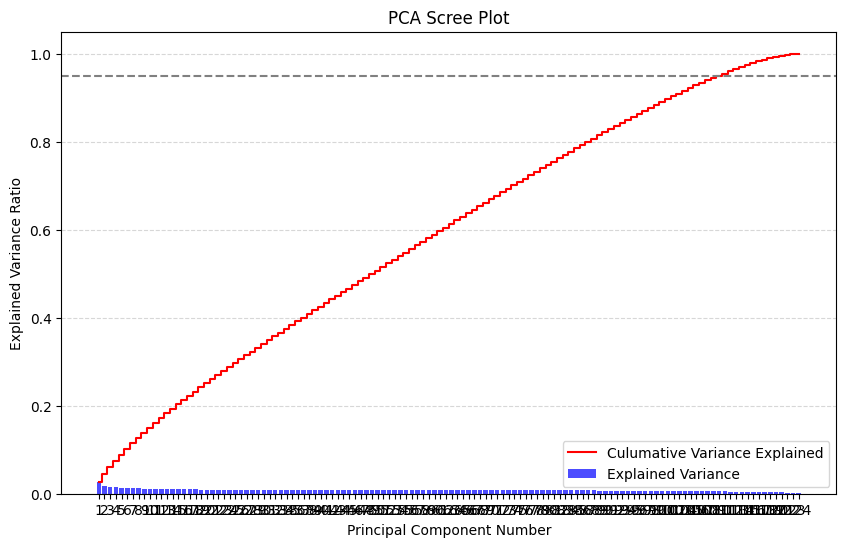

In [39]:
plt.figure(figsize=(10,6))
plt.bar(range(1,len(explained_variance_ratio)+1),explained_variance_ratio,label='Explained Variance',color='blue',alpha=0.7,align='center')
plt.step(range(1,len(cumulative_explained_variance_ratio)+1),cumulative_explained_variance_ratio,where='mid',label='Culumative Variance Explained',color='red')
plt.title('PCA Scree Plot')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Number')
plt.legend(loc='best')
plt.axhline(y=0.95,color='gray',linestyle='--',label='95% Threshold')
plt.xticks(range(1,len(cumulative_explained_variance_ratio)+1))
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

In [40]:
x_train_transformed = pca.transform(train_dataset.x)

train_features = torch.tensor(x_train_transformed, dtype=torch.float32)
train_labels = torch.tensor(train_dataset.y, dtype=torch.float32)
train_dataset = torch.utils.data.TensorDataset(train_features, train_labels)
val_features = torch.tensor(pca.transform(val_dataset.x), dtype=torch.float32)
val_labels = torch.tensor(val_dataset.y, dtype=torch.float32)
val_dataset = torch.utils.data.TensorDataset(val_features, val_labels)

In [41]:
BATCH_SIZE = 1024
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,pin_memory=True)

input_size = x_train_transformed.shape[1]
print(f"Input (features) size: {input_size}")

Input (features) size: 124


## Hyperparameter Tuning

In [46]:
learning_rates = [0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\nTesting Learning Rate: {lr}")

    # 1. Re-initialize model (Fresh start for every LR)
    # Note: Use input_size_pca if using PCA data, or dataset.x.shape[1] if using raw data
    input_dim = input_size
    temp_model = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)

    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # 2. Short Training Run (e.g., 5-10 epochs is enough to see the trend)
    for epoch in range(10):
        temp_model.train()
        for features, labels in train_loader: # Use your PCA loader here
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = temp_model(features)
            loss = criterion(outputs, labels.view(-1, 1))
            loss.backward()
            optimizer.step()

    # 3. Check Validation Loss
    mse, rmse, r2 = calculate_metrics(temp_model, val_loader, device)
    results[lr] = rmse
    print(f"LR {lr} -> Validation RMSE: {rmse:.4f}")

# Find best LR
best_lr = min(results, key=results.get)
print(f"\nBest Learning Rate found: {best_lr}")


Testing Learning Rate: 0.01
LR 0.01 -> Validation RMSE: 18.1133

Testing Learning Rate: 0.001
LR 0.001 -> Validation RMSE: 18.0685

Testing Learning Rate: 0.0001
LR 0.0001 -> Validation RMSE: 35.0028

Best Learning Rate found: 0.001


# NN

In [47]:
model = nn.Sequential(
    # Layer 1
    nn.Linear(input_size,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),
    # Layer 2
    nn.Linear(128,64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.1),
    # Layer 3
    nn.Linear(64,32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    # Layer 4
    nn.Linear(32,16),
    nn.ReLU(),
    # Layer 5
    nn.Linear(16,1)
)

model = model.to(device) # move to GPU

loss_type = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

print("Starting Training")

start_time = time.time()

for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0.0

  for features, labels in train_loader:
    features, labels = features.to(device), labels.to(device) # move data to GPU

    optimizer.zero_grad()
    # forward pass, predicted
    predictions = model(features)
    # loss
    loss = loss_type(predictions, labels.view(-1,1))
    #backprop, gradients and update weights

    loss.backward()
    optimizer.step()
    #update loss
    epoch_loss += loss.item()

  # validation test
  model.eval()
  val_loss = 0.0
  with torch.no_grad():
    for features, labels in val_loader:
      features, labels = features.to(device), labels.to(device)
      predictions = model(features)
      val_loss += loss_type(predictions, labels.view(-1,1)).item()

  avg_train_loss = epoch_loss / len(train_loader)
  avg_val_loss = val_loss / len(val_loader)

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")
  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter >= patience:
      print(f"Early stopping at epoch {epoch+1}")
      break

print("Training finished")
print(f"Done in {time.time() - start_time:.2f}s")
mse, rmse, r2 = calculate_metrics(model, val_loader, device)
print(f"Final Validation Results -> MSE: {mse:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

Starting Training
Epoch 5/100 | Train: 454.2660 | Val: 514.9729
Epoch 10/100 | Train: 256.5850 | Val: 363.9346
Epoch 15/100 | Train: 250.4020 | Val: 363.3973
Epoch 20/100 | Train: 245.4701 | Val: 362.2396
Epoch 25/100 | Train: 242.1016 | Val: 360.9919
Epoch 30/100 | Train: 239.8814 | Val: 362.6350
Epoch 35/100 | Train: 238.4898 | Val: 363.7151
Epoch 40/100 | Train: 235.6612 | Val: 360.6527
Early stopping at epoch 44
Training finished
Done in 80.01s
Final Validation Results -> MSE: 315.83 | RMSE: 17.77 | R2: 0.3044
